In [4]:
from google.colab import drive, files
drive.mount('/content/gdrive/')

import os
PROJECT_FOLDER = "/content/gdrive/MyDrive/Colab Notebooks/Thesis/Sentiment Analysis"
os.chdir(PROJECT_FOLDER)
print("Current dir: ", os.getcwd())

Drive already mounted at /content/gdrive/; to attempt to forcibly remount, call drive.mount("/content/gdrive/", force_remount=True).
Current dir:  /content/gdrive/MyDrive/Colab Notebooks/Thesis/Sentiment Analysis


In [5]:
import pandas as pd
data = pd.read_csv("AMZN_VADER_SCORE_READY_FOR_TRAINING.csv")
days = 60
seed = 412
data.head()

,Unnamed: 0,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,article-title,neg,neu,pos,compound
0,0,2021-05-10,164.115997,164.149994,159.500000,159.524506,116772000,0.0,0.0,"""'Formula One great to develop electric vans, ...",0.000,0.923,0.077,0.8850
1,1,2021-05-11,156.813995,161.899994,156.368500,161.195496,92396000,0.0,0.0,"""'Washington Post names Sally Buzbee first wom...",0.067,0.889,0.044,-0.7430
2,2,2021-05-12,159.250000,160.397003,156.654999,157.597000,98728000,0.0,0.0,"""'Sonos boosts sales outlook despite global ch...",0.065,0.829,0.106,0.8449
3,3,2021-05-13,159.273499,160.192001,156.649994,158.073502,67018000,0.0,0.0,"""'Amazon seeks renewable power for Japan data ...",0.017,0.855,0.128,0.9501
4,4,2021-05-14,159.278000,161.442993,159.149994,161.145004,66500000,0.0,0.0,"""'Less than 3% of U.S. small businesses could ...",0.014,0.914,0.072,0.9008


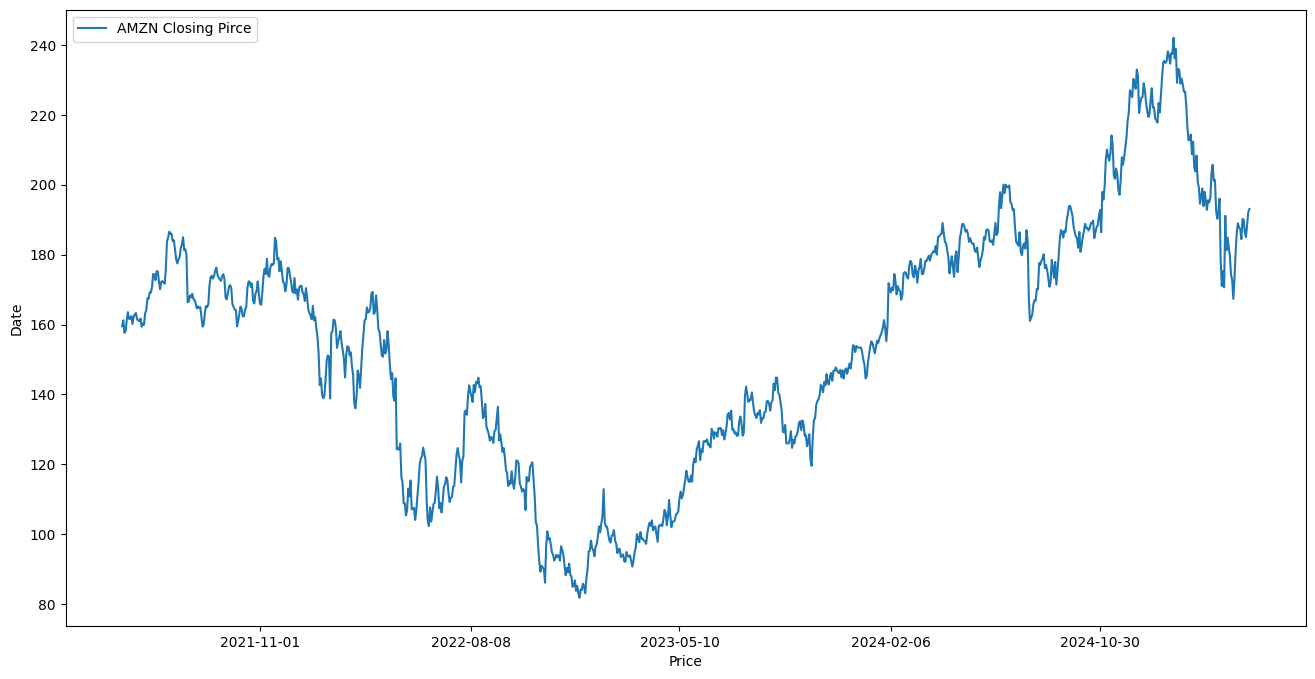

In [6]:
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib.dates as mdates
plt.figure(figsize =(16,8))
plt.plot(data['Date'], data['Close'], label = "AMZN Closing Pirce")
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xlabel("Price")
plt.ylabel("Date")
plt.legend()

Getting the inputs

In [7]:
amzn_adj_and_compound = data[['Close','compound']]
amzn_adj_and_compound.head()

,Close,compound
0,159.524506,0.8850
1,161.195496,-0.7430
2,157.597000,0.8449
3,158.073502,0.9501
4,161.145004,0.9008


Converting the inputs into an array

In [8]:
amzn_adj_and_compound_array = amzn_adj_and_compound.values
print(amzn_adj_and_compound_array)

[[159.52450562   0.885     ]
 [161.19549561  -0.743     ]
 [157.59700012   0.8449    ]
 ...
 [188.71000671  -0.2732    ]
 [192.08000183   0.8422    ]
 [193.05999756  -0.9246    ]]


Getting the date split properly for visualization later

In [9]:
dates = data['Date']
dates.head()

,Date
0,2021-05-10
1,2021-05-11
2,2021-05-12
3,2021-05-13
4,2021-05-14


Splitting the data into 80, by getting the length of the 80%

In [10]:
amzn_comp_len = int(len(amzn_adj_and_compound_array) *0.8)
print(amzn_comp_len)

785


In [11]:
training_data = amzn_adj_and_compound_array[0:amzn_comp_len]
print(training_data)
print('\n')
print("\n")
print(type(training_data))

[[159.52450562   0.885     ]
 [161.19549561  -0.743     ]
 [157.59700012   0.8449    ]
 ...
 [180.83000183   0.7845    ]
 [179.8500061    0.3818    ]
 [182.5          0.8885    ]]




<class 'numpy.ndarray'>


Scaling the training data with the MinMax Scaler

In [12]:
from sklearn.preprocessing import MinMaxScaler
x_scaler = MinMaxScaler(feature_range=(-1,1))
training_data_scaled = x_scaler.fit_transform(training_data)
print(training_data_scaled)
print("\n")
print(training_data_scaled.shape)

[[ 0.31501956  0.88567694]
 [ 0.34329829 -0.75124428]
 [ 0.28239973  0.8453572 ]
 ...
 [ 0.67557966  0.78462621]
 [ 0.65899486  0.37971947]
 [ 0.7038416   0.88919612]]


(785, 2)


In [13]:
test = amzn_adj_and_compound_array[amzn_comp_len :]
print(test.shape)

(197, 2)


Making the test set

In [14]:
test_inputs = amzn_adj_and_compound_array[len(amzn_adj_and_compound_array) - len(test) -days : ]
print(f"Test inputs without a reshape : {test_inputs.shape}")
test_inputs = test_inputs.reshape(-1, 2)
print(f"Test inputs with a reshape : {test_inputs.shape}")
test_inputs = x_scaler.transform(test_inputs)
print(f"Test inputs after transformed : {test_inputs.shape}")

Test inputs without a reshape : (257, 2)
Test inputs with a reshape : (257, 2)
Test inputs after transformed : (257, 2)


Now we are splitting the training data into inputs and labels. The inputs will be the data from the stock price of 60 days and the labels will be the next day after those 60 days. This will be shifted for each stock price until we reach the end of the training dataset

In [15]:
X_train = []
y_train = []


for i in range(days, len(training_data_scaled)):
  X_train.append(training_data_scaled[i - days: i,:])
  y_train.append(training_data_scaled[i:i+1, 0])
  if i <= days:
    print(f"These values are smaller than the {days} day minimum")

print(type(X_train))
print(type(y_train))


These values are smaller than the 60 day minimum
<class 'list'>
<class 'list'>


In order to get all the features we do training_data_scaled[i - days: i, :] where : instructs that it will keep all the features. If we did feature 0, it will  only keep the first feature, 1 the second etc

We keep the y_train and test as training/testing_data_scaled[i:i+1,0] do to wanting as label  only the closing price

In [16]:
import numpy as np
X_train, y_train = np.array(X_train), np.array(y_train)
print(X_train.shape)
print(y_train.shape)

(725, 60, 2)
(725, 1)


In [17]:
X_test = []
y_test = amzn_adj_and_compound_array[amzn_comp_len:, 0]
for i in range(days, test_inputs.shape[0]):
  X_test.append(test_inputs[i- days: i, :])

Now we convert the lists to numpy array

In [18]:
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1],2))
print(X_train.shape)
print(X_train.shape[0])
print(X_train.shape[1])

(725, 60, 2)
725
60


In [19]:
X_test = np.array(X_test)
print(X_test.shape)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1],2))
print(X_test.shape)

(197, 60, 2)
(197, 60, 2)


In [ ]:
from tensorflow.keras.models import Sequential
import tensorflow as tf
from tensorflow.keras.layers import LSTM, Dropout, Activation, Dense
model1 = Sequential()
model1.add(LSTM(units = 100, return_sequences= True, input_shape = (X_train.shape[1], 2), activation='tanh'))
model1.add(Dropout(0.2))
model1.add(LSTM(units = 100, return_sequences=True, activation='tanh'))
model1.add(Dropout(0.2))
model1.add(LSTM(units=100, return_sequences=True, activation = 'tanh'))
model1.add(Dropout(0.2))
model1.add(LSTM(units = 100, activation='tanh'))
model1.add(Dropout(0.2))
model1.add(Dense(units=1))
model1.compile(optimizer='adam', loss = 'mean_squared_error', metrics = ['mae'])
model1.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 100)        │        41,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 60, 100)        │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 60, 100)        │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 100)            │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 282,501 (1.08 MB)

 Trainable params: 282,501 (1.08 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
np.random.seed(seed)
tf.random.set_seed(seed)
history1 = model1.fit(X_train, y_train, epochs = 300, batch_size = 32)

Epoch 1/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0043 - mae: 0.0499
Epoch 2/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0048 - mae: 0.0519
Epoch 3/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0052 - mae: 0.0553
Epoch 4/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0043 - mae: 0.0500
Epoch 5/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0039 - mae: 0.0480
Epoch 6/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0043 - mae: 0.0498
Epoch 7/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0042 - mae: 0.0480
Epoch 8/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0046 - mae: 0.0514
Epoch 9/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0045 - mae: 0.0514
Epoch 10/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0040 - mae: 0.0488
Epoch 11/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0038 - mae: 0.0471
Epoch 12/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0042 - mae: 0.0494
Epoch 13/300
23/23 ━━━━━━

Text(0, 0.5, 'MAE')

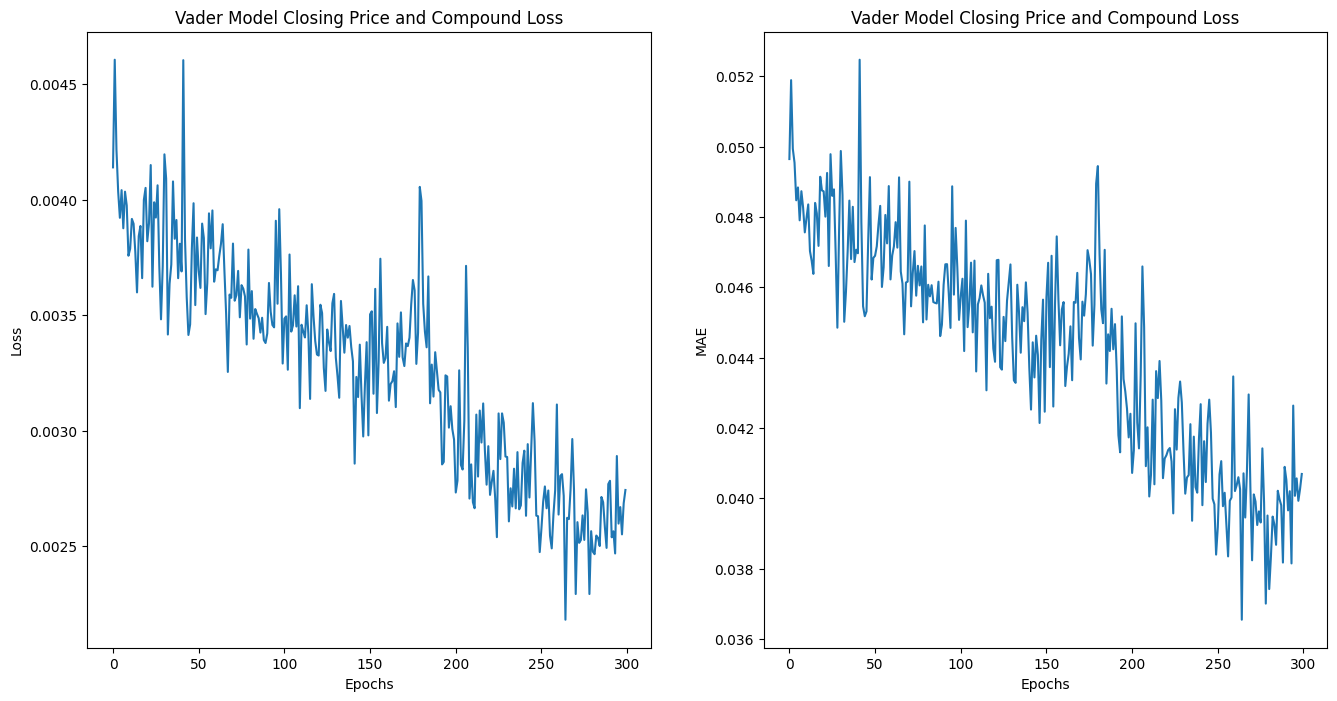

In [ ]:
plt.figure(figsize=(16,8))
plt.subplot(1,2,1)
plt.plot(history1.history['loss'], label = 'Training Loss')
plt.title("Vader Model Closing Price and Compound Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.subplot(1,2,2)
plt.plot(history1.history['mae'], label = 'Mean Absolute Error')
plt.title("Vader Model Closing Price and Compound Loss")
plt.xlabel("Epochs")
plt.ylabel("MAE")

Making the predictions set

If we have more than one feature we need to concate it together in order to inverse_transform into our dimension

In [ ]:
predictions = model1.predict(X_test)
predictions_concat = np.concatenate((predictions, np.zeros((predictions.shape[0], 1))), axis = 1)
predictions_inverted = x_scaler.inverse_transform(predictions_concat)
print(predictions_inverted)
print(predictions_concat.shape)
print(predictions.shape)
predictions = predictions_inverted[:, 0]
print(predictions)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step
[[1.78310896e+02 4.15000000e-03]
 [1.81638525e+02 4.15000000e-03]
 [1.80564761e+02 4.15000000e-03]
 [1.82660054e+02 4.15000000e-03]
 [1.83097258e+02 4.15000000e-03]
 [1.76462583e+02 4.15000000e-03]
 [1.74386585e+02 4.15000000e-03]
 [1.72156042e+02 4.15000000e-03]
 [1.73834484e+02 4.15000000e-03]
 [1.74895343e+02 4.15000000e-03]
 [1.74337558e+02 4.15000000e-03]
 [1.72858309e+02 4.15000000e-03]
 [1.72593754e+02 4.15000000e-03]
 [1.70431203e+02 4.15000000e-03]
 [1.73253767e+02 4.15000000e-03]
 [1.70439360e+02 4.15000000e-03]
 [1.72118593e+02 4.15000000e-03]
 [1.74388937e+02 4.15000000e-03]
 [1.74603486e+02 4.15000000e-03]
 [1.73810171e+02 4.15000000e-03]
 [1.75384279e+02 4.15000000e-03]
 [1.73680095e+02 4.15000000e-03]
 [1.73149581e+02 4.15000000e-03]
 [1.71169195e+02 4.15000000e-03]
 [1.70836909e+02 4.15000000e-03]
 [1.74373884e+02 4.15000000e-03]
 [1.70304184e+02 4.15000000e-03]
 [1.74965576e+02 4.15000000e-03]
 [1.76107896e+02 4.15000000e-03]
 [1.7

Calculating the RMSE

In [ ]:
rmse1 = np.sqrt(np.mean(predictions - y_test) ** 2)
print(rmse1)

12.2139116440206


Plotting the data to check


<ipython-input-30-0db855ba5f1f>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['Date'] = dates[:amzn_comp_len]
<ipython-input-30-0db855ba5f1f>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  testing['Date'] = dates[amzn_comp_len:]
<ipython-input-30-0db855ba5f1f>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_

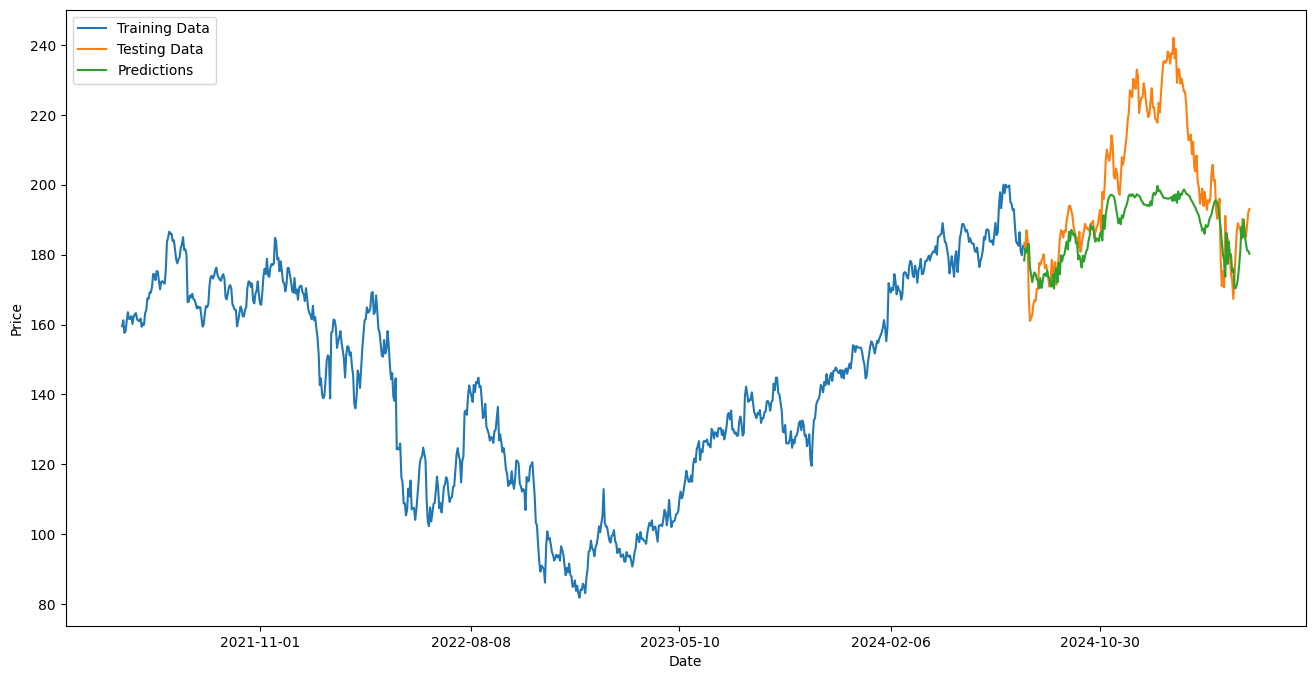

In [ ]:
train = amzn_adj_and_compound[:amzn_comp_len]
train['Date'] = dates[:amzn_comp_len]
testing = amzn_adj_and_compound[amzn_comp_len:]
testing['Date'] = dates[amzn_comp_len:]
testing['Predictions']= predictions

plt.figure(figsize=(16,8))
plt.plot(train['Date'],train['Close'], label = "Training Data")
plt.plot(testing['Date'],testing['Close'], label = "Testing Data")
plt.plot(testing['Date'], testing['Predictions'], label ="Predictions")
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()

In [ ]:
testing.head(10)

,Close,compound,Date,Predictions
785,183.199997,0.9481,2024-07-29,178.310896
786,181.710007,-0.3612,2024-07-30,181.638525
787,186.979996,0.9911,2024-07-31,180.564761
788,184.070007,0.6482,2024-08-01,182.660054
789,167.899994,0.8316,2024-08-02,183.097258
790,161.020004,-0.9643,2024-08-05,176.462583
791,161.929993,0.7003,2024-08-06,174.386585
792,162.770004,0.4404,2024-08-07,172.156042
793,165.800003,0.9623,2024-08-08,173.834484
794,166.940002,0.3506,2024-08-09,174.895343


# **Modeling with both negative and positive scores**

In [23]:
amzn_adj_scores = data[['Close','neg','pos']]
print(amzn_adj_scores.min(axis = 1))
amzn_adj_scores.head()

0      0.000
1      0.044
2      0.065
3      0.017
4      0.014
       ...  
977    0.035
978    0.044
979    0.033
980    0.020
981    0.035
Length: 982, dtype: float64


,Close,neg,pos
0,159.524506,0.000,0.077
1,161.195496,0.067,0.044
2,157.597000,0.065,0.106
3,158.073502,0.017,0.128
4,161.145004,0.014,0.072


In [24]:
amzn_adj_scores_array = amzn_adj_scores.values
print(amzn_adj_scores_array)

[[1.59524506e+02 0.00000000e+00 7.70000000e-02]
 [1.61195496e+02 6.70000000e-02 4.40000000e-02]
 [1.57597000e+02 6.50000000e-02 1.06000000e-01]
 ...
 [1.88710007e+02 3.60000000e-02 3.30000000e-02]
 [1.92080002e+02 2.00000000e-02 7.80000000e-02]
 [1.93059998e+02 8.10000000e-02 3.50000000e-02]]


In [25]:
amzn_len = int(len(amzn_adj_scores_array) *0.8)
print(amzn_len)

785


In [26]:
training_data = amzn_adj_scores_array[0:amzn_len]
print(training_data)
print('\n')
print(type(training_data))


[[1.59524506e+02 0.00000000e+00 7.70000000e-02]
 [1.61195496e+02 6.70000000e-02 4.40000000e-02]
 [1.57597000e+02 6.50000000e-02 1.06000000e-01]
 ...
 [1.80830002e+02 3.70000000e-02 7.20000000e-02]
 [1.79850006e+02 3.90000000e-02 6.00000000e-02]
 [1.82500000e+02 7.00000000e-03 5.70000000e-02]]


<class 'numpy.ndarray'>


In [27]:
x_scaler = MinMaxScaler(feature_range=(0,1))
training_data_scaled = x_scaler.fit_transform(training_data)
print(training_data_scaled)
print("\n")
print(training_data_scaled.shape)

[[0.65750978 0.         0.1974359 ]
 [0.67164914 0.26070039 0.11282051]
 [0.64119987 0.25291829 0.27179487]
 ...
 [0.83778983 0.14396887 0.18461538]
 [0.82949743 0.15175097 0.15384615]
 [0.8519208  0.02723735 0.14615385]]


(785, 3)


In [28]:
test = amzn_adj_scores_array[amzn_len:]
print(test.shape)

(197, 3)


In [29]:
test_inputs = amzn_adj_scores_array[len(amzn_adj_scores_array) - len(test) -days : ]
print(f"Test inputs without a reshape : {test_inputs.shape}")
test_inputs = test_inputs.reshape(-1, 3)
print(f"Test inputs with a reshape : {test_inputs.shape}")
test_inputs = x_scaler.transform(test_inputs)
print(f"Test inputs after transformed : {test_inputs.shape}")

Test inputs without a reshape : (257, 3)
Test inputs with a reshape : (257, 3)
Test inputs after transformed : (257, 3)


In [30]:
X_train = []
y_train = []


for i in range(days, len(training_data_scaled)):
  X_train.append(training_data_scaled[i - days: i,:])
  y_train.append(training_data_scaled[i:i+1, 0])
  if i <= days:
    print(f"These values are smaller than the {days} day minimum")

print(type(X_train))
print(type(y_train))


These values are smaller than the 60 day minimum
<class 'list'>
<class 'list'>


In [31]:
X_train, y_train = np.array(X_train), np.array(y_train)
print(X_train.shape)
print(y_train.shape)

(725, 60, 3)
(725, 1)


In [32]:
X_test = []
y_test = amzn_adj_scores_array[amzn_len:, 0]
for i in range(days, test_inputs.shape[0]):
  X_test.append(test_inputs[i- days: i, :])

In [33]:
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1],3))
print(X_train.shape)
print(X_train.shape[0])
print(X_train.shape[1])

(725, 60, 3)
725
60


In [34]:
X_test = np.array(X_test)
print(X_test.shape)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1],3))
print(X_test.shape)

(197, 60, 3)
(197, 60, 3)


Training the model

In [ ]:
model2 = Sequential()
model2.add(LSTM(units = 100, return_sequences= True, input_shape = (X_train.shape[1], 3), activation='tanh'))
model2.add(Dropout(0.2))
model2.add(LSTM(units = 100, return_sequences=True, activation='tanh'))
model2.add(Dropout(0.2))
model2.add(LSTM(units=100, return_sequences=True, activation = 'tanh'))
model2.add(Dropout(0.2))
model2.add(LSTM(units = 100, activation='tanh'))
model2.add(Dropout(0.2))
model2.add(Dense(units=1))
model2.compile(optimizer='adam', loss = 'mean_squared_error', metrics = ['mae'])
model2.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 60, 100)        │        41,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 60, 100)        │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 60, 100)        │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 100)            │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 282,901 (1.08 MB)

 Trainable params: 282,901 (1.08 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
np.random.seed(seed)
tf.random.set_seed(seed)
history2 = model2.fit(X_train, y_train, epochs = 300, batch_size = 32)

Epoch 1/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.1086 - mae: 0.2421
Epoch 2/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0095 - mae: 0.0761
Epoch 3/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0091 - mae: 0.0750
Epoch 4/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0085 - mae: 0.0713
Epoch 5/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0077 - mae: 0.0682
Epoch 6/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0078 - mae: 0.0687
Epoch 7/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0088 - mae: 0.0735
Epoch 8/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0084 - mae: 0.0715
Epoch 9/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0061 - mae: 0.0605
Epoch 10/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0072 - mae: 0.0655
Epoch 11/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0074 - mae: 0.0653
Epoch 12/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0070 - mae: 0.0650
Epoch 13/300
23/23 ━━━━━━

This is the same as the other one,  where we have to concatinate and the change the number 2 in this case, to the amount of features - 1 (if we have 3 features like in this case it will be 3 -1  )

Text(0, 0.5, 'MAE')

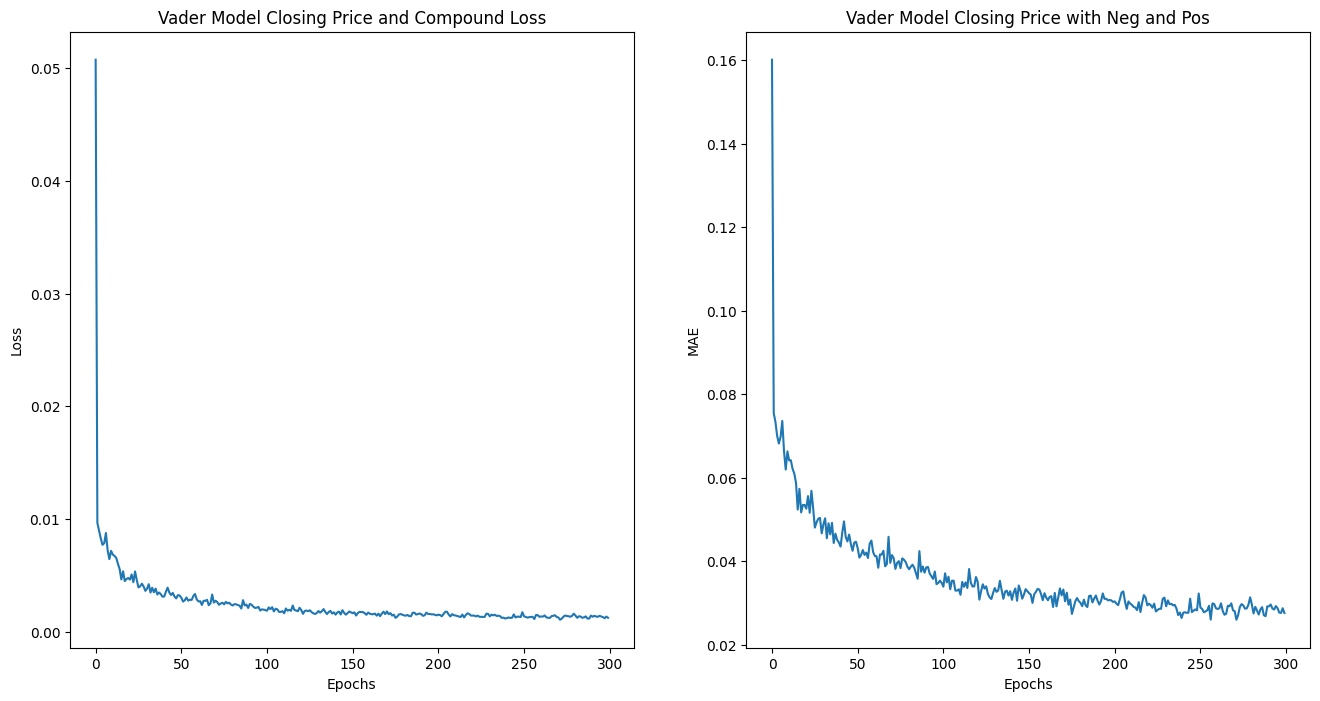

In [ ]:
plt.figure(figsize=(16,8))
plt.subplot(1,2,1)
plt.plot(history2.history['loss'], label = 'Training Loss')
plt.title("Vader Model Closing Price and Compound Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.subplot(1,2,2)
plt.plot(history2.history['mae'], label = 'Mean Absolute Error')
plt.title("Vader Model Closing Price with Neg and Pos")
plt.xlabel("Epochs")
plt.ylabel("MAE")

In [ ]:
predictions = model2.predict(X_test)
predictions_concat = np.concatenate((predictions, np.zeros((predictions.shape[0], 2))), axis = 1)
predictions_inverted = x_scaler.inverse_transform(predictions_concat)
predictions = predictions_inverted[:, 0]

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step


In [ ]:
rmse2 = np.sqrt(np.mean(predictions - y_test) ** 2)
print(rmse2)

4.841469642676571


<ipython-input-49-b883e110bd32>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train2['Date'] = dates[:amzn_comp_len]
<ipython-input-49-b883e110bd32>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  testing2['Date'] = dates[amzn_comp_len:]
<ipython-input-49-b883e110bd32>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/use

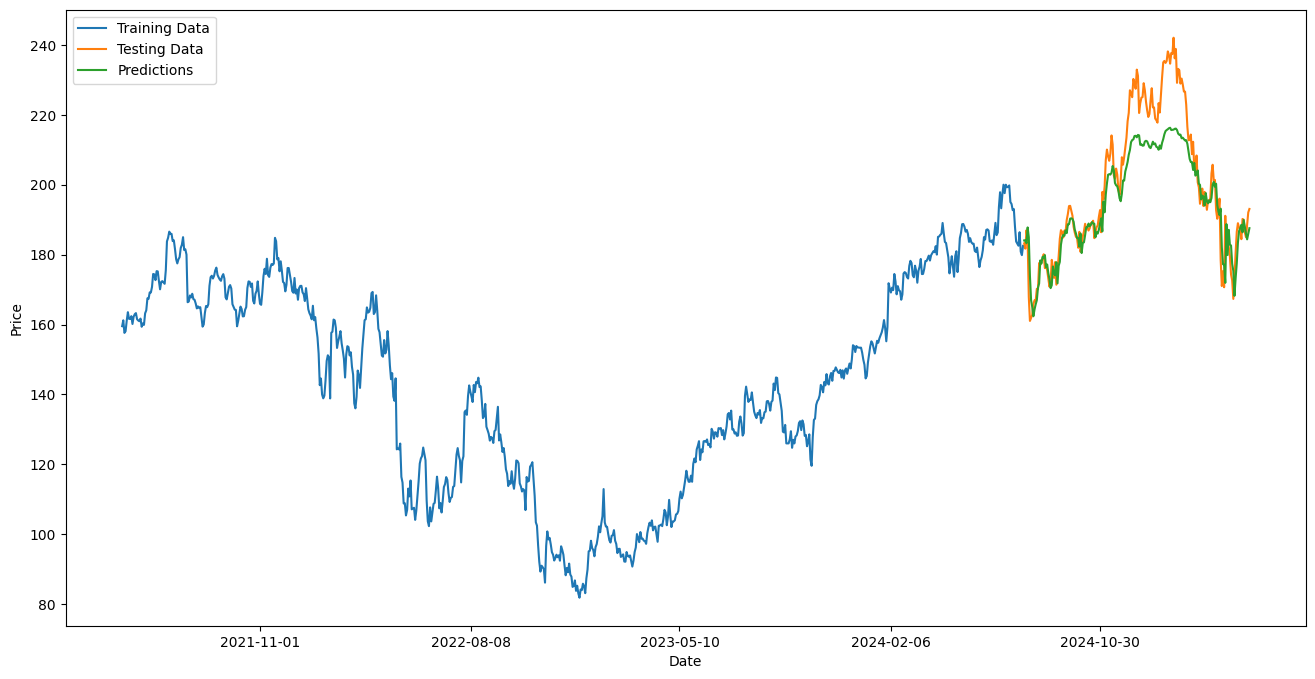

In [ ]:
train2 = amzn_adj_scores[:amzn_comp_len]
train2['Date'] = dates[:amzn_comp_len]
testing2 = amzn_adj_scores[amzn_comp_len:]
testing2['Date'] = dates[amzn_comp_len:]
testing2['Predictions']= predictions

plt.figure(figsize=(16,8))
plt.plot(train2['Date'],train2['Close'], label = "Training Data")
plt.plot(testing2['Date'],testing2['Close'], label = "Testing Data")
plt.plot(testing2['Date'], testing2['Predictions'], label ="Predictions")
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()

In [ ]:
testing2.head()

,Close,neg,pos,Date,Predictions
785,183.199997,0.006,0.046,2024-07-29,184.056908
786,181.710007,0.049,0.038,2024-07-30,184.102455
787,186.979996,0.043,0.152,2024-07-31,183.267591
788,184.070007,0.052,0.052,2024-08-01,187.772694
789,167.899994,0.054,0.072,2024-08-02,185.012627


# **Modeling with both negative and positive scores and neutral scores, and compound**

In [37]:
amzn_data = data[['Close','Open','High','Low','neg','neu','pos','compound']]
amzn_data.head()

,Close,Open,High,Low,neg,neu,pos,compound
0,159.524506,164.115997,164.149994,159.500000,0.000,0.923,0.077,0.8850
1,161.195496,156.813995,161.899994,156.368500,0.067,0.889,0.044,-0.7430
2,157.597000,159.250000,160.397003,156.654999,0.065,0.829,0.106,0.8449
3,158.073502,159.273499,160.192001,156.649994,0.017,0.855,0.128,0.9501
4,161.145004,159.278000,161.442993,159.149994,0.014,0.914,0.072,0.9008


In [38]:
amzn_data_array = amzn_data.values
print(amzn_data_array)

[[ 1.59524506e+02  1.64115997e+02  1.64149994e+02 ...  9.23000000e-01
   7.70000000e-02  8.85000000e-01]
 [ 1.61195496e+02  1.56813995e+02  1.61899994e+02 ...  8.89000000e-01
   4.40000000e-02 -7.43000000e-01]
 [ 1.57597000e+02  1.59250000e+02  1.60397003e+02 ...  8.29000000e-01
   1.06000000e-01  8.44900000e-01]
 ...
 [ 1.88710007e+02  1.85559998e+02  1.90990005e+02 ...  9.31000000e-01
   3.30000000e-02 -2.73200000e-01]
 [ 1.92080002e+02  1.91429993e+02  1.94330002e+02 ...  9.02000000e-01
   7.80000000e-02  8.42200000e-01]
 [ 1.93059998e+02  1.93380005e+02  1.94690002e+02 ...  8.85000000e-01
   3.50000000e-02 -9.24600000e-01]]


In [39]:
amzn_len = int(len(amzn_data_array) *0.8)
print(amzn_len)

785


In [40]:
training_data = amzn_data_array[0:amzn_len]
print(training_data)
print('\n')
print(type(training_data))

[[ 1.59524506e+02  1.64115997e+02  1.64149994e+02 ...  9.23000000e-01
   7.70000000e-02  8.85000000e-01]
 [ 1.61195496e+02  1.56813995e+02  1.61899994e+02 ...  8.89000000e-01
   4.40000000e-02 -7.43000000e-01]
 [ 1.57597000e+02  1.59250000e+02  1.60397003e+02 ...  8.29000000e-01
   1.06000000e-01  8.44900000e-01]
 ...
 [ 1.80830002e+02  1.83199997e+02  1.85449997e+02 ...  8.91000000e-01
   7.20000000e-02  7.84500000e-01]
 [ 1.79850006e+02  1.82910004e+02  1.83899994e+02 ...  9.01000000e-01
   6.00000000e-02  3.81800000e-01]
 [ 1.82500000e+02  1.80389999e+02  1.83190002e+02 ...  9.36000000e-01
   5.70000000e-02  8.88500000e-01]]


<class 'numpy.ndarray'>


In [41]:
x_scaler = MinMaxScaler(feature_range=(-1,1))
training_data_scaled = x_scaler.fit_transform(training_data)
print(training_data_scaled)
print("\n")
print(training_data_scaled.shape)

[[ 0.31501956  0.38658025  0.37054018 ...  0.64351852 -0.60512821
   0.88567694]
 [ 0.34329829  0.26206832  0.33231388 ...  0.48611111 -0.77435897
  -0.75124428]
 [ 0.28239973  0.30360647  0.30677887 ...  0.20833333 -0.45641026
   0.8453572 ]
 ...
 [ 0.67557966  0.7119959   0.73241589 ...  0.49537037 -0.63076923
   0.78462621]
 [ 0.65899486  0.70705101  0.70608216 ...  0.54166667 -0.69230769
   0.37971947]
 [ 0.7038416   0.66408052  0.69401978 ...  0.7037037  -0.70769231
   0.88919612]]


(785, 8)


In [42]:
test = amzn_data_array[amzn_len:]
print(test.shape)

(197, 8)


In [43]:
test_inputs = amzn_data_array[len(amzn_data) - len(test) -days : ]
print(f"Test inputs without a reshape : {test_inputs.shape}")
test_inputs = test_inputs.reshape(-1, 8)
print(f"Test inputs with a reshape : {test_inputs.shape}")
test_inputs = x_scaler.transform(test_inputs)
print(f"Test inputs after transformed : {test_inputs.shape}")

Test inputs without a reshape : (257, 8)
Test inputs with a reshape : (257, 8)
Test inputs after transformed : (257, 8)


In [44]:
X_train = []
y_train = []

for i in range(days, len(training_data_scaled)):
  X_train.append(training_data_scaled[i - days: i,:])
  y_train.append(training_data_scaled[i:i+1, 0])
  if i <= days:
    print(f"These values are smaller than the {days} day minimum")

print(type(X_train))
print(type(y_train))


These values are smaller than the 60 day minimum
<class 'list'>
<class 'list'>


In [45]:
X_train, y_train = np.array(X_train), np.array(y_train)
print(X_train.shape)
print(y_train.shape)

(725, 60, 8)
(725, 1)


In [46]:
X_test = []
y_test = amzn_data_array[amzn_len:, 0]
for i in range(days, test_inputs.shape[0]):
  X_test.append(test_inputs[i- days: i, :])

In [47]:
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1],8))
print(X_train.shape)
print(X_train.shape[0])
print(X_train.shape[1])

(725, 60, 8)
725
60


In [48]:
X_test = np.array(X_test)
print(X_test.shape)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1],8))
print(X_test.shape)

(197, 60, 8)
(197, 60, 8)


Training the 3rd model

In [ ]:
model3 = Sequential()
model3.add(LSTM(units = 100, return_sequences= True, input_shape = (X_train.shape[1], 8), activation='tanh'))
model3.add(Dropout(0.2))
model3.add(LSTM(units = 100, return_sequences=True, activation='tanh'))
model3.add(Dropout(0.2))
model3.add(LSTM(units=100, return_sequences=True, activation = 'tanh'))
model3.add(Dropout(0.2))
model3.add(LSTM(units = 100, activation='tanh'))
model3.add(Dropout(0.2))
model3.add(Dense(units=1))
model3.compile(optimizer='adam', loss = 'mean_squared_error', metrics = ['mae'])
model3.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                   │ (None, 60, 100)        │        43,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 60, 100)        │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ (None, 60, 100)        │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 100)            │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 284,901 (1.09 MB)

 Trainable params: 284,901 (1.09 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
np.random.seed(seed)
tf.random.set_seed(seed)
history3 = model3.fit(X_train, y_train, epochs = 300, batch_size = 32)

Epoch 1/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.0991 - mae: 0.2402
Epoch 2/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0249 - mae: 0.1233
Epoch 3/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0205 - mae: 0.1138
Epoch 4/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0184 - mae: 0.1063
Epoch 5/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0185 - mae: 0.1055
Epoch 6/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0180 - mae: 0.1064
Epoch 7/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0171 - mae: 0.1013
Epoch 8/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0143 - mae: 0.0930
Epoch 9/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0141 - mae: 0.0937
Epoch 10/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0144 - mae: 0.0927
Epoch 11/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0140 - mae: 0.0907
Epoch 12/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0121 - mae: 0.0851
Epoch 13/300
23/23 ━━━━━━

Text(0, 0.5, 'MAE')

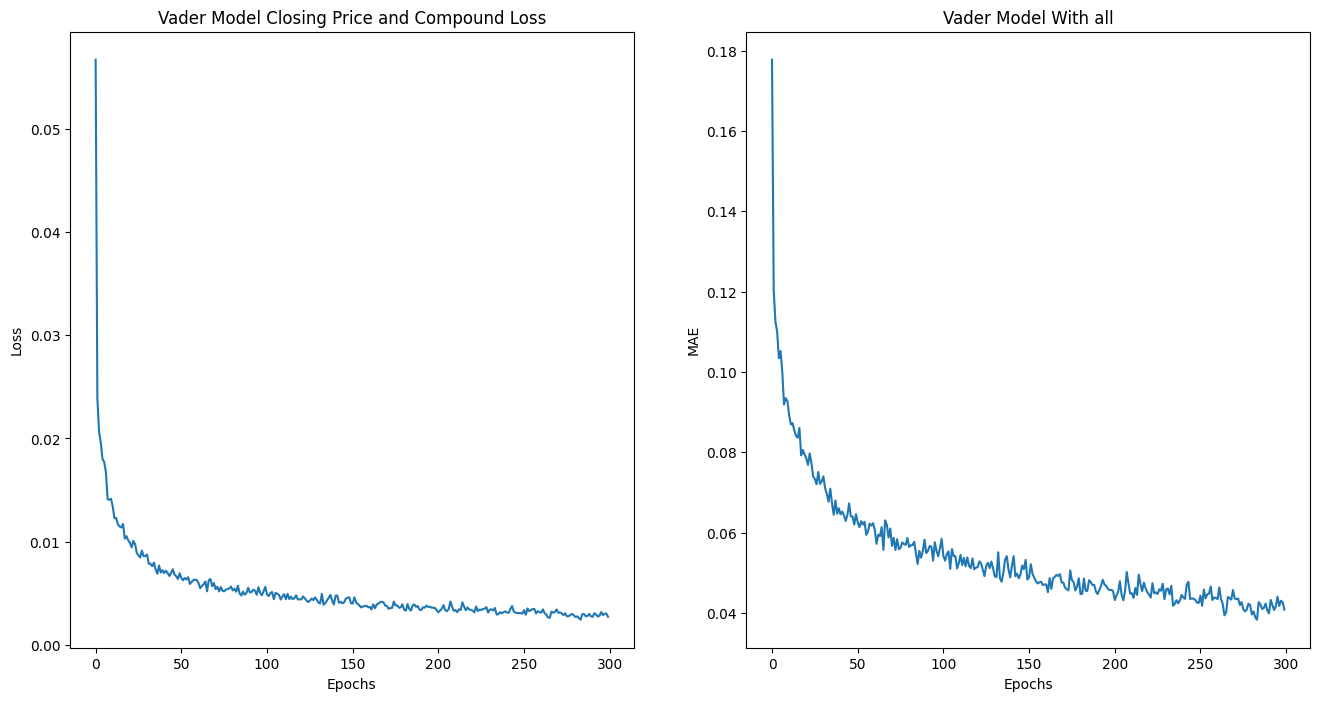

In [ ]:
plt.figure(figsize=(16,8))
plt.subplot(1,2,1)
plt.plot(history3.history['loss'], label = 'Training Loss')
plt.title("Vader Model Closing Price and Compound Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.subplot(1,2,2)
plt.plot(history3.history['mae'], label = 'Mean Absolute Error')
plt.title("Vader Model With all")
plt.xlabel("Epochs")
plt.ylabel("MAE")

In [ ]:
predictions = model3.predict(X_test)
predictions_concat = np.concatenate((predictions, np.zeros((predictions.shape[0], 7))), axis = 1)
predictions_inverted = x_scaler.inverse_transform(predictions_concat)
predictions = predictions_inverted[:, 0]

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [ ]:
rmse3 = np.sqrt(np.mean(predictions - y_test) ** 2)
print(rmse3)

10.866182893938896


<ipython-input-70-1d5cd43c47de>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train3['Date'] = dates[:amzn_comp_len]
<ipython-input-70-1d5cd43c47de>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  testing3['Date'] = dates[amzn_comp_len:]
<ipython-input-70-1d5cd43c47de>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/use

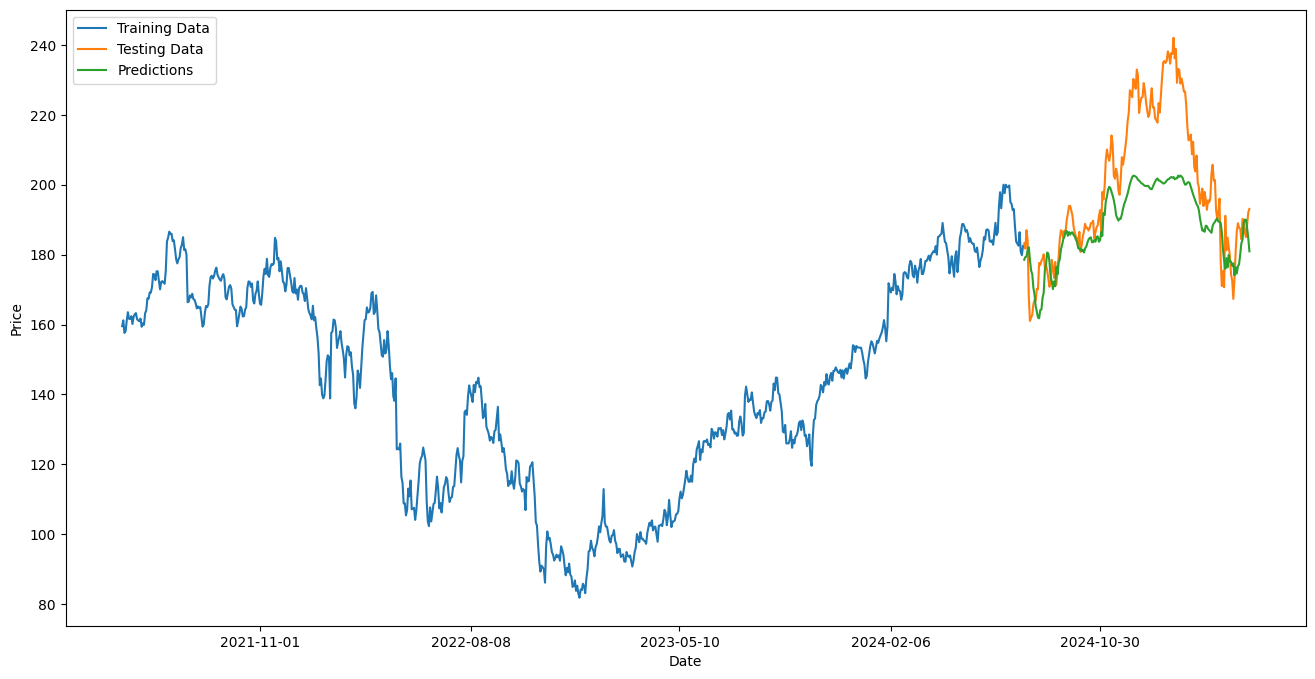

In [ ]:
train3 = amzn_data[:amzn_comp_len]
train3['Date'] = dates[:amzn_comp_len]
testing3 = amzn_data[amzn_comp_len:]
testing3['Date'] = dates[amzn_comp_len:]
testing3['Predictions']= predictions

plt.figure(figsize=(16,8))
plt.plot(train3['Date'],train3['Close'], label = "Training Data")
plt.plot(testing3['Date'],testing3['Close'], label = "Testing Data")
plt.plot(testing3['Date'], testing3['Predictions'], label ="Predictions")
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()

In [ ]:
testing3.head()

,Close,Open,High,Low,neg,neu,pos,compound,Date,Predictions
785,183.199997,183.839996,184.750000,182.380005,0.006,0.948,0.046,0.9481,2024-07-29,178.533218
786,181.710007,184.720001,185.860001,179.380005,0.049,0.913,0.038,-0.3612,2024-07-30,179.316058
787,186.979996,185.050003,187.940002,184.460007,0.043,0.805,0.152,0.9911,2024-07-31,179.452413
788,184.070007,189.289993,190.600006,181.869995,0.052,0.896,0.052,0.6482,2024-08-01,181.247727
789,167.899994,166.750000,168.770004,160.550003,0.054,0.874,0.072,0.8316,2024-08-02,182.153091


# **Model with only the Close and sentiment scores of vader**

In [51]:
amzn_data = data[['Close','neg','neu','pos','compound']]
amzn_data.head()

,Close,neg,neu,pos,compound
0,159.524506,0.000,0.923,0.077,0.8850
1,161.195496,0.067,0.889,0.044,-0.7430
2,157.597000,0.065,0.829,0.106,0.8449
3,158.073502,0.017,0.855,0.128,0.9501
4,161.145004,0.014,0.914,0.072,0.9008


In [52]:
amzn_data_array = amzn_data.values
print(amzn_data_array)

[[ 1.59524506e+02  0.00000000e+00  9.23000000e-01  7.70000000e-02
   8.85000000e-01]
 [ 1.61195496e+02  6.70000000e-02  8.89000000e-01  4.40000000e-02
  -7.43000000e-01]
 [ 1.57597000e+02  6.50000000e-02  8.29000000e-01  1.06000000e-01
   8.44900000e-01]
 ...
 [ 1.88710007e+02  3.60000000e-02  9.31000000e-01  3.30000000e-02
  -2.73200000e-01]
 [ 1.92080002e+02  2.00000000e-02  9.02000000e-01  7.80000000e-02
   8.42200000e-01]
 [ 1.93059998e+02  8.10000000e-02  8.85000000e-01  3.50000000e-02
  -9.24600000e-01]]


In [53]:
amzn_len = int(len(amzn_data_array) *0.8)
print(amzn_len)

785


In [54]:
training_data = amzn_data_array[0:amzn_len]
print(training_data)
print('\n')
print(type(training_data))

[[ 1.59524506e+02  0.00000000e+00  9.23000000e-01  7.70000000e-02
   8.85000000e-01]
 [ 1.61195496e+02  6.70000000e-02  8.89000000e-01  4.40000000e-02
  -7.43000000e-01]
 [ 1.57597000e+02  6.50000000e-02  8.29000000e-01  1.06000000e-01
   8.44900000e-01]
 ...
 [ 1.80830002e+02  3.70000000e-02  8.91000000e-01  7.20000000e-02
   7.84500000e-01]
 [ 1.79850006e+02  3.90000000e-02  9.01000000e-01  6.00000000e-02
   3.81800000e-01]
 [ 1.82500000e+02  7.00000000e-03  9.36000000e-01  5.70000000e-02
   8.88500000e-01]]


<class 'numpy.ndarray'>


In [55]:
x_scaler = MinMaxScaler(feature_range=(-1,1))
training_data_scaled = x_scaler.fit_transform(training_data)
print(training_data_scaled)
print("\n")
print(training_data_scaled.shape)

[[ 0.31501956 -1.          0.64351852 -0.60512821  0.88567694]
 [ 0.34329829 -0.47859922  0.48611111 -0.77435897 -0.75124428]
 [ 0.28239973 -0.49416342  0.20833333 -0.45641026  0.8453572 ]
 ...
 [ 0.67557966 -0.71206226  0.49537037 -0.63076923  0.78462621]
 [ 0.65899486 -0.69649805  0.54166667 -0.69230769  0.37971947]
 [ 0.7038416  -0.94552529  0.7037037  -0.70769231  0.88919612]]


(785, 5)


In [56]:
test = amzn_data_array[amzn_len:]
print(test.shape)

(197, 5)


In [57]:
test_inputs = amzn_data_array[len(amzn_data) - len(test) -days : ]
print(f"Test inputs without a reshape : {test_inputs.shape}")
test_inputs = test_inputs.reshape(-1, 5)
print(f"Test inputs with a reshape : {test_inputs.shape}")
test_inputs = x_scaler.transform(test_inputs)
print(f"Test inputs after transformed : {test_inputs.shape}")

Test inputs without a reshape : (257, 5)
Test inputs with a reshape : (257, 5)
Test inputs after transformed : (257, 5)


In [58]:
X_train = []
y_train = []


for i in range(days, len(training_data_scaled)):
  X_train.append(training_data_scaled[i - days: i,:])
  y_train.append(training_data_scaled[i:i+1, 0])
  if i <= days:
    print(f"These values are smaller than the {days} day minimum")

print(type(X_train))
print(type(y_train))

These values are smaller than the 60 day minimum
<class 'list'>
<class 'list'>


In [59]:
X_train, y_train = np.array(X_train), np.array(y_train)
print(X_train.shape)
print(y_train.shape)

(725, 60, 5)
(725, 1)


In [60]:
X_test = []
y_test = amzn_data_array[amzn_len:, 0]
for i in range(days, test_inputs.shape[0]):
  X_test.append(test_inputs[i- days: i, :])

In [61]:
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1],5))
print(X_train.shape)
print(X_train.shape[0])
print(X_train.shape[1])

(725, 60, 5)
725
60


In [62]:
X_test = np.array(X_test)
print(X_test.shape)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1],5))
print(X_test.shape)

(197, 60, 5)
(197, 60, 5)


Training the 4th model

In [ ]:
model4 = Sequential()
model4.add(LSTM(units = 100, return_sequences= True, input_shape = (X_train.shape[1], 5), activation='tanh'))
model4.add(Dropout(0.2))
model4.add(LSTM(units = 100, return_sequences=True, activation='tanh'))
model4.add(Dropout(0.2))
model4.add(LSTM(units=100, return_sequences=True, activation = 'tanh'))
model4.add(Dropout(0.2))
model4.add(LSTM(units = 100, activation='tanh'))
model4.add(Dropout(0.2))
model4.add(Dense(units=1))
model4.compile(optimizer='adam', loss = 'mean_squared_error', metrics = ['mae'])
model4.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_12 (LSTM)                  │ (None, 60, 100)        │        42,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 60, 100)        │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_14 (LSTM)                  │ (None, 60, 100)        │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_15 (LSTM)                  │ (None, 100)            │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 283,701 (1.08 MB)

 Trainable params: 283,701 (1.08 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
np.random.seed(seed)
tf.random.set_seed(seed)
history4 = model4.fit(X_train, y_train, epochs = 300, batch_size = 32)

Epoch 1/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.1176 - mae: 0.2725
Epoch 2/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0301 - mae: 0.1371
Epoch 3/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0237 - mae: 0.1206
Epoch 4/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0226 - mae: 0.1185
Epoch 5/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0198 - mae: 0.1116
Epoch 6/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0196 - mae: 0.1106
Epoch 7/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0191 - mae: 0.1106
Epoch 8/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0170 - mae: 0.1032
Epoch 9/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0159 - mae: 0.0983
Epoch 10/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0149 - mae: 0.0943
Epoch 11/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0148 - mae: 0.0946
Epoch 12/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0141 - mae: 0.0935
Epoch 13/300
23/23 ━━━━━━

Text(0, 0.5, 'MAE')

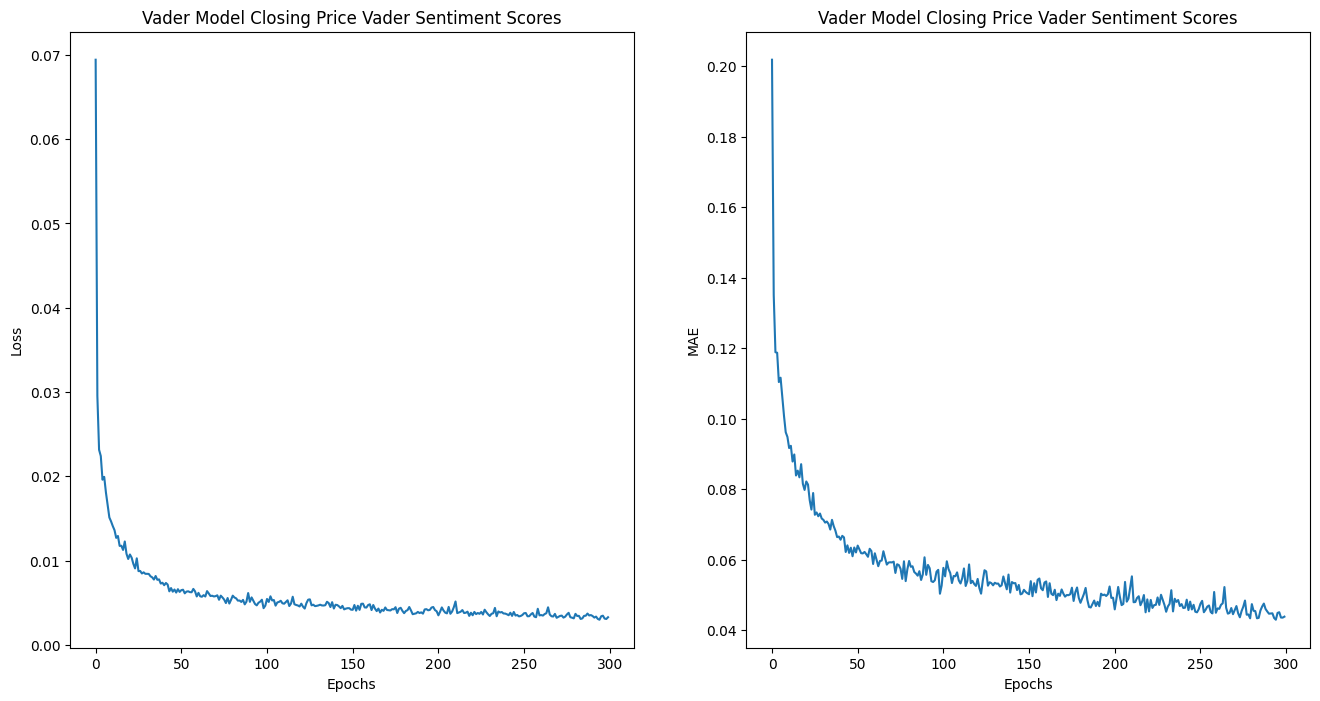

In [ ]:
plt.figure(figsize=(16,8))
plt.subplot(1,2,1)
plt.plot(history4.history['loss'], label = 'Training Loss')
plt.title("Vader Model Closing Price Vader Sentiment Scores")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.subplot(1,2,2)
plt.plot(history4.history['mae'], label = 'Mean Absolute Error')
plt.title("Vader Model Closing Price Vader Sentiment Scores")
plt.xlabel("Epochs")
plt.ylabel("MAE")

In [ ]:
predictions = model4.predict(X_test)
predictions_concat = np.concatenate((predictions, np.zeros((predictions.shape[0], 4))), axis = 1)
predictions_inverted = x_scaler.inverse_transform(predictions_concat)
predictions = predictions_inverted[:, 0]

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step


In [ ]:
rmse4 = np.sqrt(np.mean(predictions - y_test) ** 2)
print(rmse4)

11.68005107373405


<ipython-input-91-9edb5046622c>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train4['Date'] = dates[:amzn_comp_len]
<ipython-input-91-9edb5046622c>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  testing4['Date'] = dates[amzn_comp_len:]
<ipython-input-91-9edb5046622c>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/use

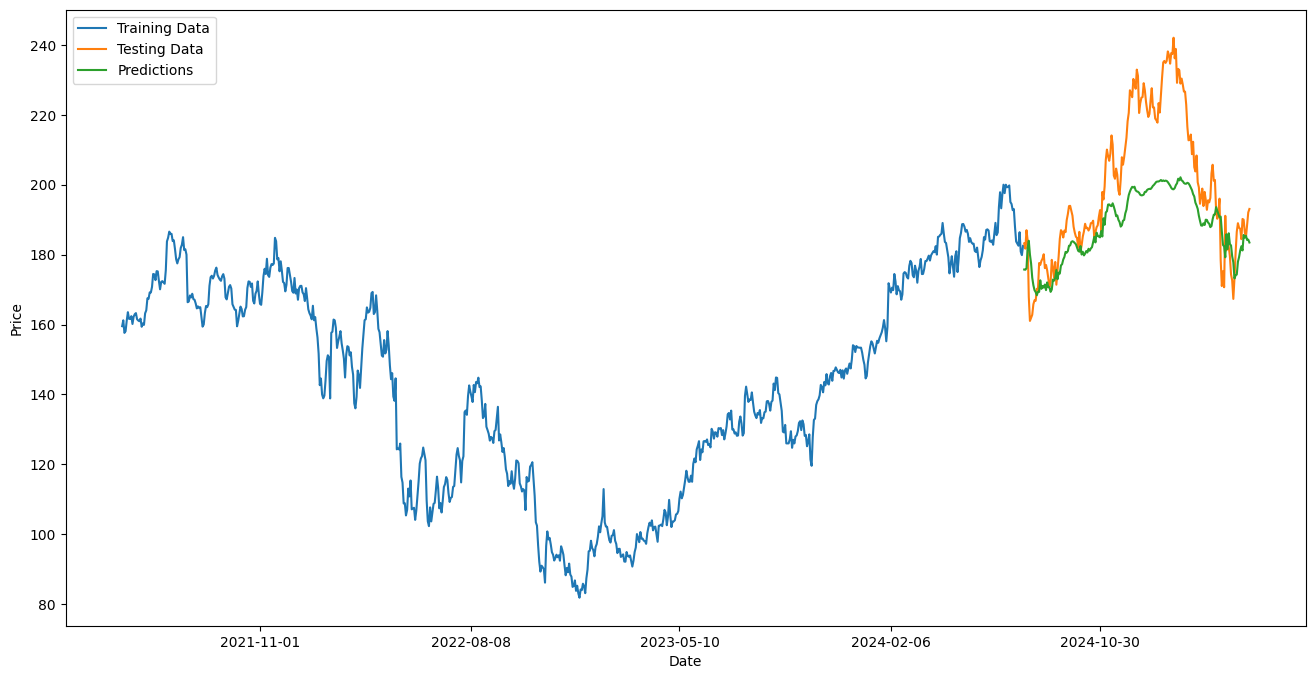

In [ ]:
train4 = amzn_data[:amzn_comp_len]
train4['Date'] = dates[:amzn_comp_len]
testing4 = amzn_data[amzn_comp_len:]
testing4['Date'] = dates[amzn_comp_len:]
testing4['Predictions']= predictions

plt.figure(figsize=(16,8))
plt.plot(train4['Date'],train4['Close'], label = "Training Data")
plt.plot(testing4['Date'],testing4['Close'], label = "Testing Data")
plt.plot(testing4['Date'], testing4['Predictions'], label ="Predictions")
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()

In [ ]:
testing4.head()

,Close,neg,neu,pos,compound,Date,Predictions
785,183.199997,0.006,0.948,0.046,0.9481,2024-07-29,175.728724
786,181.710007,0.049,0.913,0.038,-0.3612,2024-07-30,175.665349
787,186.979996,0.043,0.805,0.152,0.9911,2024-07-31,176.098309
788,184.070007,0.052,0.896,0.052,0.6482,2024-08-01,181.883846
789,167.899994,0.054,0.874,0.072,0.8316,2024-08-02,183.959510


# **Save the models in pickle files**

In [ ]:
!pip install -q joblib

In [2]:
PROJECT_FOLDER = "/content/gdrive/MyDrive/Colab Notebooks/Thesis/Models"
os.chdir(PROJECT_FOLDER)
print(os.getcwd())

/content/gdrive/MyDrive/Colab Notebooks/Thesis/Models


In [ ]:
import joblib
joblib.dump(model1, "VADER_Model1.pkl")
joblib.dump(model2, "VADER_Model2.pkl")
joblib.dump(model3, "VADER_Model3.pkl")
joblib.dump(model4, "VADER_Model4.pkl")

['VADER_Model4.pkl']

# **Graph Comparison**

In [3]:
import joblib
model1 = joblib.load('VADER_Model1.pkl')
model2 = joblib.load('VADER_Model2.pkl')
model3 = joblib.load('VADER_Model3.pkl')
model4 = joblib.load('VADER_Model4.pkl')

Model 1

In [20]:
predictions = model1.predict(X_test)
predictions_concat = np.concatenate((predictions, np.zeros((predictions.shape[0], 1))), axis = 1)
predictions_inverted = x_scaler.inverse_transform(predictions_concat)
print(predictions_inverted)
print(predictions_concat.shape)
print(predictions.shape)
predictions = predictions_inverted[:, 0]
print(predictions)

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 154ms/step
[[1.78310893e+02 4.15000000e-03]
 [1.81638508e+02 4.15000000e-03]
 [1.80564751e+02 4.15000000e-03]
 [1.82660043e+02 4.15000000e-03]
 [1.83097244e+02 4.15000000e-03]
 [1.76462587e+02 4.15000000e-03]
 [1.74386581e+02 4.15000000e-03]
 [1.72156035e+02 4.15000000e-03]
 [1.73834491e+02 4.15000000e-03]
 [1.74895322e+02 4.15000000e-03]
 [1.74337551e+02 4.15000000e-03]
 [1.72858298e+02 4.15000000e-03]
 [1.72593744e+02 4.15000000e-03]
 [1.70431196e+02 4.15000000e-03]
 [1.73253760e+02 4.15000000e-03]
 [1.70439360e+02 4.15000000e-03]
 [1.72118582e+02 4.15000000e-03]
 [1.74388930e+02 4.15000000e-03]
 [1.74603475e+02 4.15000000e-03]
 [1.73810168e+02 4.15000000e-03]
 [1.75384272e+02 4.15000000e-03]
 [1.73680092e+02 4.15000000e-03]
 [1.73149571e+02 4.15000000e-03]
 [1.71169181e+02 4.15000000e-03]
 [1.70836895e+02 4.15000000e-03]
 [1.74373870e+02 4.15000000e-03]
 [1.70304184e+02 4.15000000e-03]
 [1.74965565e+02 4.15000000e-03]
 [1.76107889e+02 4.15000000e-03]
 [1.

In [22]:
train = amzn_adj_and_compound[:amzn_comp_len]
train['Date'] = dates[:amzn_comp_len]
testing = amzn_adj_and_compound[amzn_comp_len:]
testing['Date'] = dates[amzn_comp_len:]
testing['Predictions']= predictions

<ipython-input-22-a783f250bd2c>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['Date'] = dates[:amzn_comp_len]
<ipython-input-22-a783f250bd2c>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  testing['Date'] = dates[amzn_comp_len:]
<ipython-input-22-a783f250bd2c>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_

In [35]:
predictions = model2.predict(X_test)
predictions_concat = np.concatenate((predictions, np.zeros((predictions.shape[0], 2))), axis = 1)
predictions_inverted = x_scaler.inverse_transform(predictions_concat)
print(predictions_inverted)
print(predictions_concat.shape)
print(predictions.shape)
predictions = predictions_inverted[:, 0]
print(predictions)

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 203ms/step
[[184.05687299   0.           0.        ]
 [184.10242704   0.           0.        ]
 [183.26756304   0.           0.        ]
 [187.77266584   0.           0.        ]
 [185.01260631   0.           0.        ]
 [173.87324392   0.           0.        ]
 [166.95808063   0.           0.        ]
 [164.99870019   0.           0.        ]
 [162.35711499   0.           0.        ]
 [164.30994444   0.           0.        ]
 [165.76889956   0.           0.        ]
 [166.95827787   0.           0.        ]
 [170.53889488   0.           0.        ]
 [171.74912365   0.           0.        ]
 [178.34470421   0.           0.        ]
 [177.43583514   0.           0.        ]
 [179.35282432   0.           0.        ]
 [179.01157402   0.           0.        ]
 [179.87495948   0.           0.        ]
 [176.36707961   0.           0.        ]
 [177.17675399   0.           0.        ]
 [174.68468636   0.           0.        ]
 [172.96463548   0.           0.     

In [36]:
train2 = amzn_adj_scores[:amzn_comp_len]
train2['Date'] = dates[:amzn_comp_len]
testing2 = amzn_adj_scores[amzn_comp_len:]
testing2['Date'] = dates[amzn_comp_len:]
testing2['Predictions']= predictions

<ipython-input-36-788f3943fe66>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train2['Date'] = dates[:amzn_comp_len]
<ipython-input-36-788f3943fe66>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  testing2['Date'] = dates[amzn_comp_len:]
<ipython-input-36-788f3943fe66>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/use

In [49]:
predictions = model3.predict(X_test)
predictions_concat = np.concatenate((predictions, np.zeros((predictions.shape[0], 7))), axis = 1)
predictions_inverted = x_scaler.inverse_transform(predictions_concat)
predictions = predictions_inverted[:, 0]

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 158ms/step


In [50]:
train3 = amzn_data[:amzn_comp_len]
train3['Date'] = dates[:amzn_comp_len]
testing3 = amzn_data[amzn_comp_len:]
testing3['Date'] = dates[amzn_comp_len:]
testing3['Predictions']= predictions

<ipython-input-50-560e693444d6>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train3['Date'] = dates[:amzn_comp_len]
<ipython-input-50-560e693444d6>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  testing3['Date'] = dates[amzn_comp_len:]
<ipython-input-50-560e693444d6>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/use

In [63]:
predictions = model4.predict(X_test)
predictions_concat = np.concatenate((predictions, np.zeros((predictions.shape[0], 4))), axis = 1)
predictions_inverted = x_scaler.inverse_transform(predictions_concat)
predictions = predictions_inverted[:, 0]

7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 243ms/step


In [64]:
train4 = amzn_data[:amzn_comp_len]
train4['Date'] = dates[:amzn_comp_len]
testing4 = amzn_data[amzn_comp_len:]
testing4['Date'] = dates[amzn_comp_len:]
testing4['Predictions']= predictions

<ipython-input-64-36a462aadacd>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train4['Date'] = dates[:amzn_comp_len]
<ipython-input-64-36a462aadacd>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  testing4['Date'] = dates[amzn_comp_len:]
<ipython-input-64-36a462aadacd>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/use

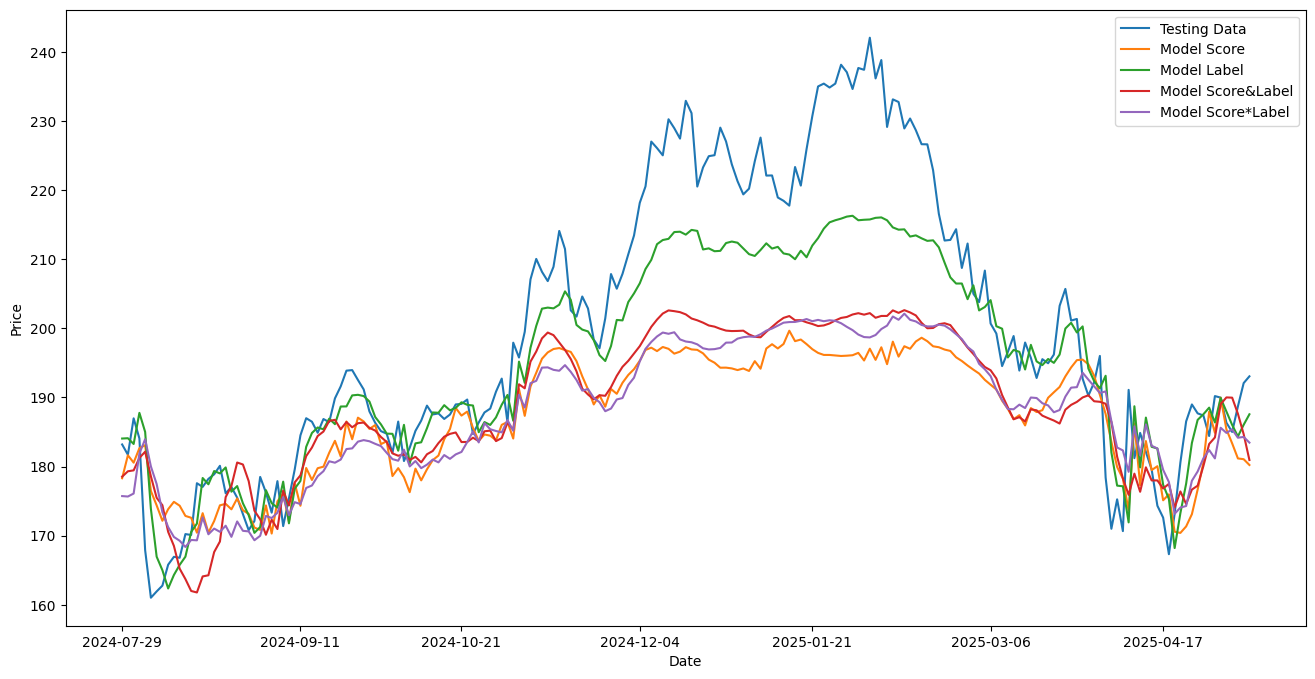

In [65]:
plt.figure(figsize=(16,8))
plt.plot(testing['Date'],testing['Close'], label = "Testing Data")
plt.plot(testing['Date'], testing['Predictions'], label ="Model Score")

plt.plot(testing2['Date'],testing2['Predictions'], label = "Model Label")
plt.plot(testing3['Date'],testing3['Predictions'], label = "Model Score&Label")
plt.plot(testing4['Date'], testing4['Predictions'], label ="Model Score*Label")
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()